In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [33]:
binary_splice_performances = {
    'BPsiRandomForest': {'MCC': 0.12, 'AUC': 0.56, 'Balanced Accuracy': 0.56, 'F1 Score': 0.41, 'note': 'proper splits'},
    'BPsiHistoneConvSE': {'MCC': 0.20, 'AUC': 0.64, 'Balanced Accuracy': 0.60, 'F1 Score': 0.62, 'note': '+-70bp around the junction -> same for 120bp'},
    'BPsiHistoneConvSE+AR': {'MCC': 0.27, 'AUC': 0.75, 'Balanced Accuracy': 0.67, 'F1 Score': 0.89, 'note': ''},
    'BPsiMergedCellLineSE': {'MCC': 0.36, 'AUC': 0.73, 'Balanced Accuracy': 0.67, 'F1 Score': 0.73, 'note': 'Also conv model'},
    'BPsiESPRNNSE': {'MCC': 0.11, 'AUC': 0.57, 'Balanced Accuracy': 0.55, 'F1 Score': 0.60, 'note': 'model adapted from keras'},
    'BPsiESPRNNNaiveSE': {'MCC': 0.30, 'AUC': 0.71, 'Balanced Accuracy': 0.65, 'F1 Score': 0.70, 'note': 'Naive data splits'},
    'BPsiESPRNNNormSE': {'MCC': 0.34, 'AUC': 0.75, 'Balanced Accuracy': 0.66, 'F1 Score': 0.72, 'note': 'Normalization across all data'},
    'BPsiFullSE': {'MCC': 0.20, 'AUC': 0.64, 'Balanced Accuracy': 0.60, 'F1 Score': 0.67, 'note': 'Full model with seq encoder and attention'},
    'BPsiFullSE+AR': {'MCC': 0.28, 'AUC': 0.79, 'Balanced Accuracy': 0.56, 'F1 Score': 0.95, 'note': ''}
    }

b_psi_df = pd.DataFrame(binary_splice_performances)
b_psi_df

,BPsiRandomForest,BPsiHistoneConvSE,BPsiHistoneConvSE+AR,BPsiMergedCellLineSE,BPsiESPRNNSE,BPsiESPRNNNaiveSE,BPsiESPRNNNormSE,BPsiFullSE,BPsiFullSE+AR
MCC,0.12,0.2,0.27,0.36,0.11,0.3,0.34,0.2,0.28
AUC,0.56,0.64,0.75,0.73,0.57,0.71,0.75,0.64,0.79
Balanced Accuracy,0.56,0.6,0.67,0.67,0.55,0.65,0.66,0.6,0.56
F1 Score,0.41,0.62,0.89,0.73,0.6,0.7,0.72,0.67,0.95
note,proper splits,+-70bp around the junction -> same for 120bp,,Also conv model,model adapted from keras,Naive data splits,Normalization across all data,Full model with seq encoder and attention,


In [34]:
b_psi_df = b_psi_df.reset_index().melt(id_vars="index", var_name="Model", value_name="Score")
b_psi_df.rename(columns={"index": "Metric"}, inplace=True)

In [35]:
palette

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254),
 (0.4, 0.7607843137254902, 0.6470588235294118)]

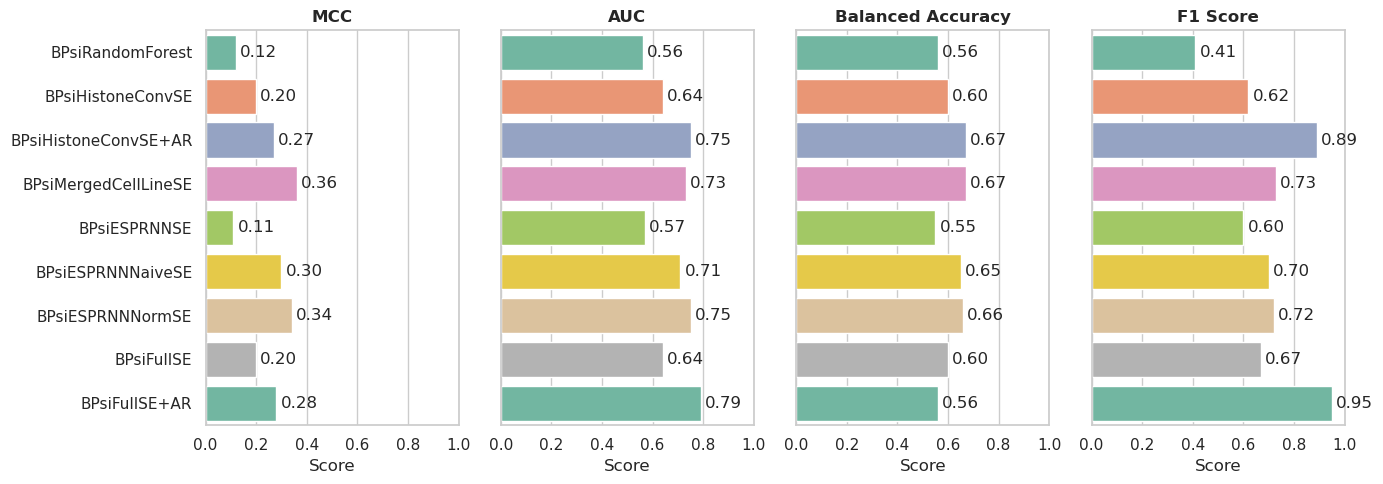

In [37]:
# plot per metric
palette = sns.color_palette("Set2", n_colors=b_psi_df["Model"].nunique())
fig, ax = plt.subplots(1, 4, figsize=(14, 5), sharey=True)
axes = ax.flatten()

metrics = b_psi_df["Metric"].unique()

for i, metric in enumerate(metrics):
    if metric == 'note':
        continue
    ax = axes[i]
    sns.barplot(
        data=b_psi_df[b_psi_df["Metric"] == metric],
        x="Score", y="Model", ax=ax, orient="h",
        hue="Model", dodge=False, palette=palette
    )
    ax.set_title(metric, fontsize=12, weight="bold")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Score")
    ax.set_ylabel("")  # remove redundant label
    ax.legend([],[], frameon=False)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", label_type="edge", padding=3)

handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=False)

plt.tight_layout()
plt.savefig("../images/bpsi_performances.png", dpi=300)
plt.show()